In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
from pathlib import Path

import datasets as hfds
import torch
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

import flat_mae.transforms as flat_transforms
import flat_mae.data as flat_data
import flat_mae.models_mae as models_mae
import flat_mae.nisc as nisc

In [3]:
torch.backends.cudnn.benchmark = True

In [4]:
plt.style.use("../clane.v2.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [5]:
# get some data
# note, hardcoded params from the config
dataset_root = "s3://medarc/fmri-datasets/eval"
space = "flat"
img_size = (224, 560)
patch_size = 16
t_patch_size = 4

transform = flat_transforms.make_transform(space, normalize="frame")
dataset = hfds.load_dataset(
    "arrow",
    data_files=f"{dataset_root}/hcpya-clips.{space}.arrow/test/*.arrow",
    split="train",
)
dataset = flat_data.HFDataset(dataset, transform)

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

In [6]:
nsd_dataset = hfds.load_dataset(
    "arrow",
    data_files=f"{dataset_root}/nsd-cococlip.{space}.arrow/testid/*.arrow",
    split="train",
)
nsd_dataset = flat_data.HFDataset(nsd_dataset, transform)

Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

In [7]:
device = torch.device("cuda")

In [13]:
keys = ["attn_reg1_pep4", "crossreg_reg4_pep4"]
models = {}

for key in keys:
    ckpt_path = f"output/decoders/{key}/pretrain/checkpoint-last.pth"
    models[key] = models_mae.MaskedAutoencoderViT.from_checkpoint(ckpt_path).to(device)

In [9]:
@torch.inference_mode()
def denoising_recon(
    model: models_mae.MaskedAutoencoderViT,
    dataset,
    device,
    sample_idx: int = 0,
):
    sample = dataset[sample_idx]

    bold = sample["bold"].to(device).unsqueeze(0)
    mask = sample["mask"].to(device).expand_as(bold)

    # for full context denoising, we use mask ratio 0 and decode all patches
    # let's see if this works!
    _, state = model.forward(
        bold,
        img_mask=mask,
        mask_ratio=0.0,
        with_state=True,
        pred_edge_pad=0,
        full_decoding=True,
    )

    pred_images = state["pred_images"]
    pred_mask = state["pred_mask"]
    return bold, pred_images, pred_mask, mask

In [10]:
def plot_pred_row(
    images: torch.Tensor,
    pred_images: torch.Tensor,
    pred_mask: torch.Tensor,
    img_mask: torch.Tensor,
    stride: int = 2,
):
    images = images.squeeze().cpu().numpy()
    pred_images = pred_images.squeeze().cpu().numpy()
    pred_mask = pred_mask.squeeze().cpu().numpy()
    img_mask = img_mask[0, 0, 0].cpu().numpy()

    pred_images = pred_images * pred_mask

    T, H, W = pred_images.shape
    ploth = 1.0
    plotw = (W / H) * ploth
    nrow = 2
    ncol = T // stride
    fig, axs = plt.subplots(nrow, ncol, figsize=(plotw * ncol, ploth * nrow), squeeze=False)

    for jj in range(ncol):
        plt.sca(axs[0, jj])
        _imshow(images[jj * stride], img_mask)

        plt.sca(axs[1, jj])
        _imshow(pred_images[jj * stride], img_mask)

    axs[0, 0].set_ylabel("image")
    axs[1, 0].set_ylabel("denoised")

    for jj in range(ncol):
        axs[0, jj].set_title(f"t = {jj * stride}s")

    fig.subplots_adjust(
        left=0.02,
        right=1.0,
        bottom=0.0,
        top=0.98,
        wspace=0.02,
        hspace=0.02,
    )
    return fig


def _imshow(image, mask, vmin=-3, vmax=3, cmap=nisc.FC_CMAP):
    plt.imshow(np.where(mask, image, np.nan), cmap=cmap, vmin=vmin, vmax=vmax, interpolation="none")
    plt.xticks([])
    plt.yticks([])
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(False)

In [11]:
# key = "attn_reg1_pep4"
key = "crossreg_reg4_pep4"
sample_id = 1550

images, pred_images, pred_mask, img_mask = denoising_recon(
    models[key],
    dataset=dataset,
    device=device,
    sample_idx=sample_id,
)
print(images.shape, pred_images.shape, pred_mask.shape, img_mask.shape)

torch.Size([1, 1, 16, 224, 560]) torch.Size([1, 1, 16, 224, 560]) torch.Size([1, 1, 16, 224, 560]) torch.Size([1, 1, 16, 224, 560])


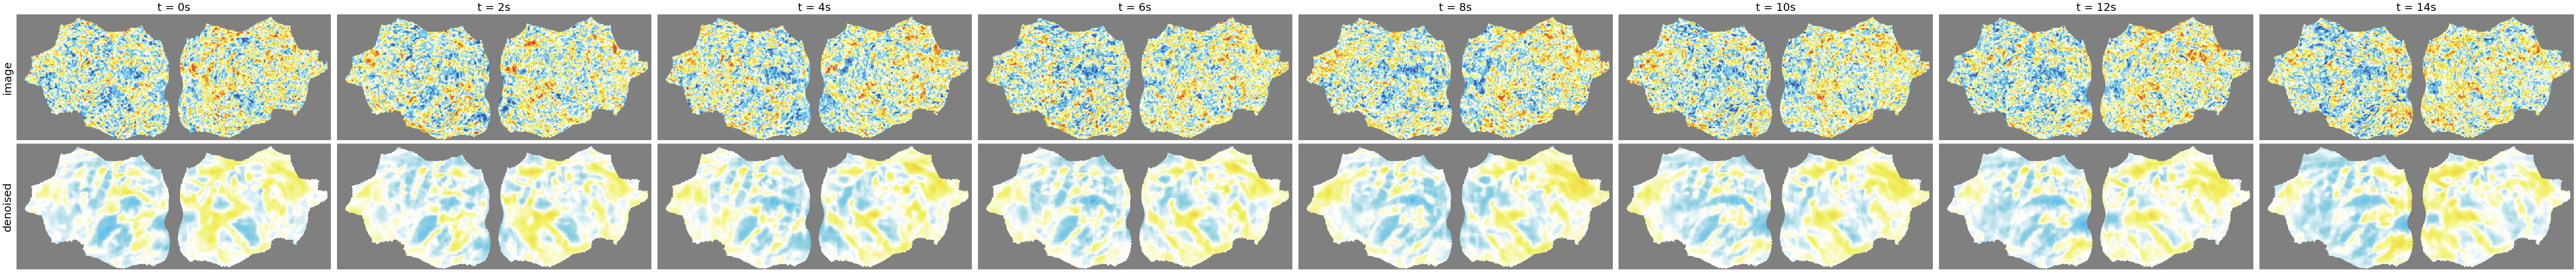

In [12]:
f = plot_pred_row(images, pred_images, pred_mask, img_mask);

In [14]:
outdir = Path("results/denoising_full")
outdir.mkdir(exist_ok=True, parents=True)

rng = np.random.default_rng(42)
sample_ids = rng.choice(len(dataset), 20, replace=False)

for key in keys:
    model = models[key]
    torch.manual_seed(42)

    for ii, sample_id in tqdm(enumerate(sample_ids[:10])):
        images, pred_images, pred_mask, img_mask = denoising_recon(
            model,
            dataset=dataset,
            device=device,
            sample_idx=sample_id,
        )
        f = plot_pred_row(images, pred_images, pred_mask, img_mask)

        outpath = outdir / f"denoise_full_hcp_{key}_{ii:02d}_{sample_id:04d}.png"
        f.savefig(outpath, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(f)

0it [00:00, ?it/s]

10it [00:06,  1.63it/s]
10it [00:06,  1.61it/s]


In [ ]:
for key in keys:
    model = models[key]
    torch.manual_seed(42)

    for ii, sample_id in tqdm(enumerate(sample_ids[:10])):
        images, pred_images, pred_mask, img_mask = denoising_recon(
            model,
            dataset=nsd_dataset,
            device=device,
            sample_idx=sample_id,
        )
        f = plot_pred_row(images, pred_images, pred_mask, img_mask)

        outpath = outdir / f"denoise_full_nsd_{key}_{ii:02d}_{sample_id:04d}.png"
        f.savefig(outpath, dpi=200, bbox_inches="tight", pad_inches=0)
        plt.close(f)

10it [00:05,  1.77it/s]
10it [00:06,  1.52it/s]
